## 📝 Instrucciones


**Sistema de predicción de ventas**

Queremos establecer el almacén de nuestra empresa en otra localización y necesitamos estimar el ritmo de las ventas, que desde la creación de la empresa ha ido en aumento, para los próximos meses, a fin de proveer el espacio que necesitaremos.

## Paso 1: Carga del conjunto de datos


El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre sales.csv. Puedes cargarlos en el código directamente desde el siguiente enlace:

''https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv''

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima


In [2]:
df = pd.read_csv('../data/raw/sales.csv')
print(df.head())

                         date      sales
0  2022-09-03 17:10:08.079328  55.292157
1  2022-09-04 17:10:08.079328  53.803211
2  2022-09-05 17:10:08.079328  58.141693
3  2022-09-06 17:10:08.079328  64.530899
4  2022-09-07 17:10:08.079328  66.013633


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    str    
 1   sales   366 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


In [4]:
df.shape

(366, 2)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sales,366.0,524.963968,275.089698,53.803211,290.186822,520.699468,763.289263,1000.482785


In [6]:
#parseamos date y lo ponemos cono índice
ser = pd.read_csv('../data/raw/sales.csv', parse_dates=['date'], index_col='date')
ser.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


## Paso 2: Construye y analiza la serie temporal


Construye la estructura de datos válida para la serie temporal, grafícala y, a continuación, analízala y responde a las siguientes preguntas:

**¿Cuál es el tensor de la serie temporal?**

**¿Cuál es la tendencia?**

**¿Es estacionaria?**

**¿Existe variabilidad o presencia de ruido?**

_Nota: Un tensor en una serie temporal es la unidad de tiempo mínima para la cual hay datos. Puede ser cada segundo, minuto, hora, día, semana, mes.._

<Axes: xlabel='date'>

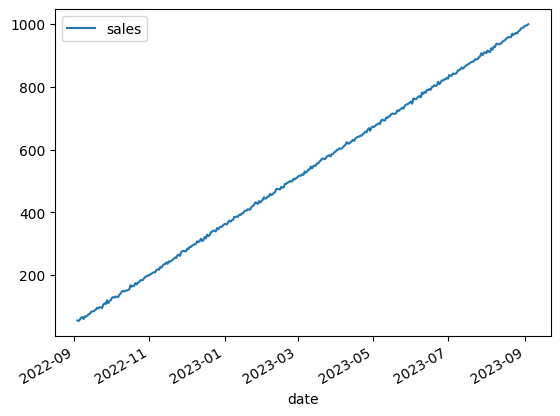

In [15]:
ser.plot(grid=False)

In [7]:
ser.index.to_series().diff()

date
2022-09-03 17:10:08.079328      NaT
2022-09-04 17:10:08.079328   1 days
2022-09-05 17:10:08.079328   1 days
2022-09-06 17:10:08.079328   1 days
2022-09-07 17:10:08.079328   1 days
                              ...  
2023-08-30 17:10:08.079328   1 days
2023-08-31 17:10:08.079328   1 days
2023-09-01 17:10:08.079328   1 days
2023-09-02 17:10:08.079328   1 days
2023-09-03 17:10:08.079328   1 days
Name: date, Length: 366, dtype: timedelta64[us]

**El tensor es diario** Ahora miremos la tendencia:

<Axes: xlabel='date'>

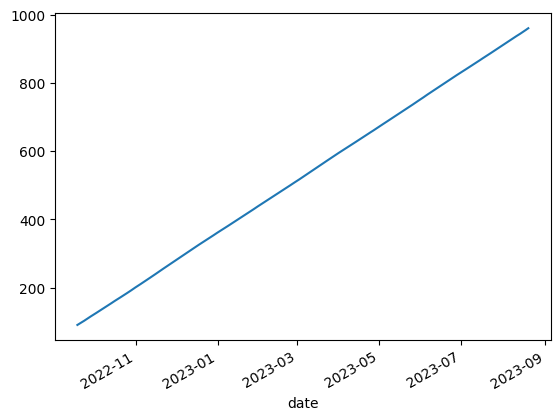

In [30]:
decomposition = seasonal_decompose(ser, model='additive', period=30)
trend = decomposition.trend
trend.plot()

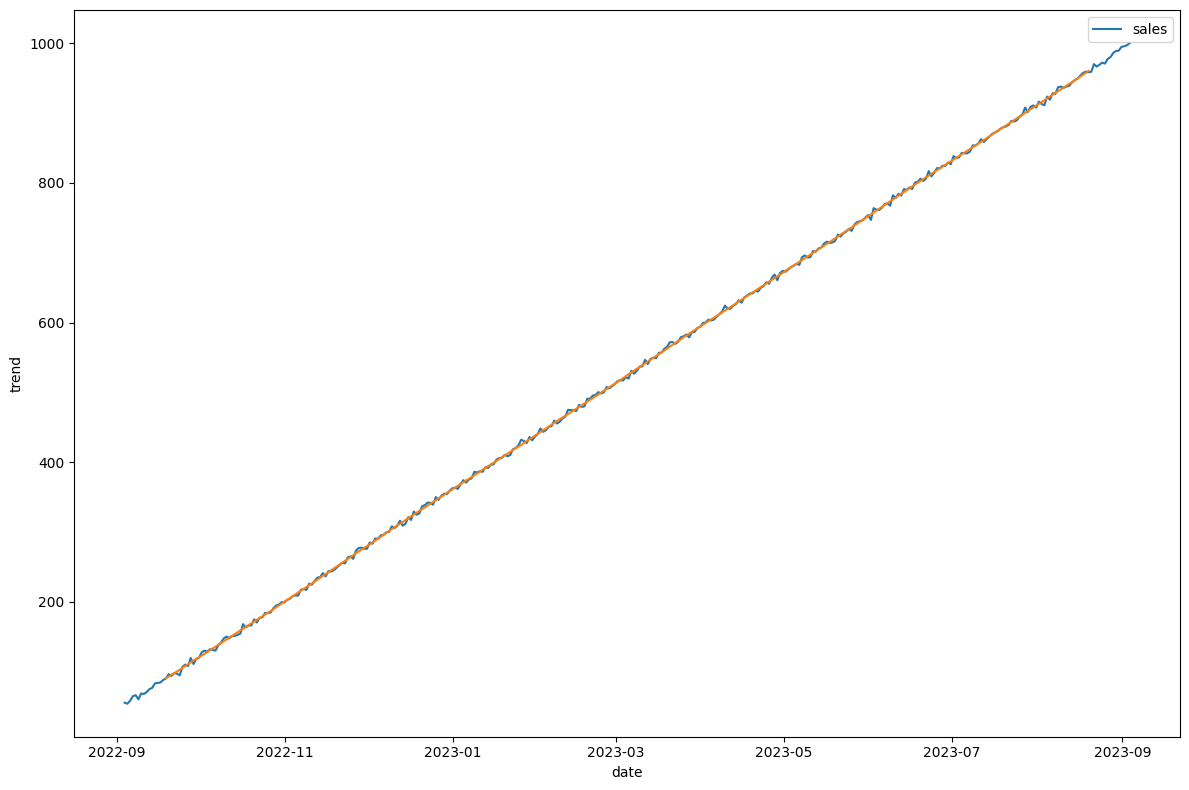

In [31]:
fig, axes = plt.subplots(figsize=(12, 8))
sns.lineplot(data=ser, ax=axes)
sns.lineplot(data=trend, ax=axes)
plt.tight_layout()
plt.show()

**He decidido cambiar la frecuencia de los datos para mejorar la visualización e interpretación del análisis.**

<Axes: xlabel='date'>

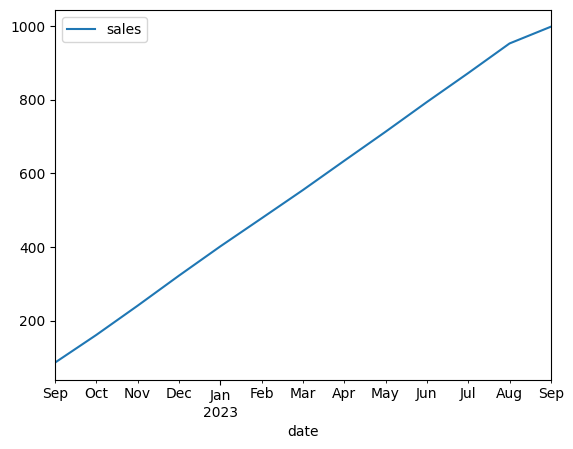

In [32]:
ser_mensual = ser.resample('ME').mean()
ser_mensual.plot()

**La tendencia es claramente ascendente y casi perfectamente lineal** Para evaluar la estacionalidad aplicamos el test **Dickey-Fuller**

In [ ]:
def test_stationarity(timeseries):
    print('Resultado de la Prueba de Dickey-Fuller:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    return dfoutput

test_stationarity(ser)

Resultado de la Prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

Con un p-value de **0.986** (mayor que 0.05 alpha) se puede rechazar la hipótesis nula de no estacionariedad. **Por lo tanto la serie no es estacionaria.** 

Sólo falta conocer la variabilidad para poder entrenar un modelo ARIMA

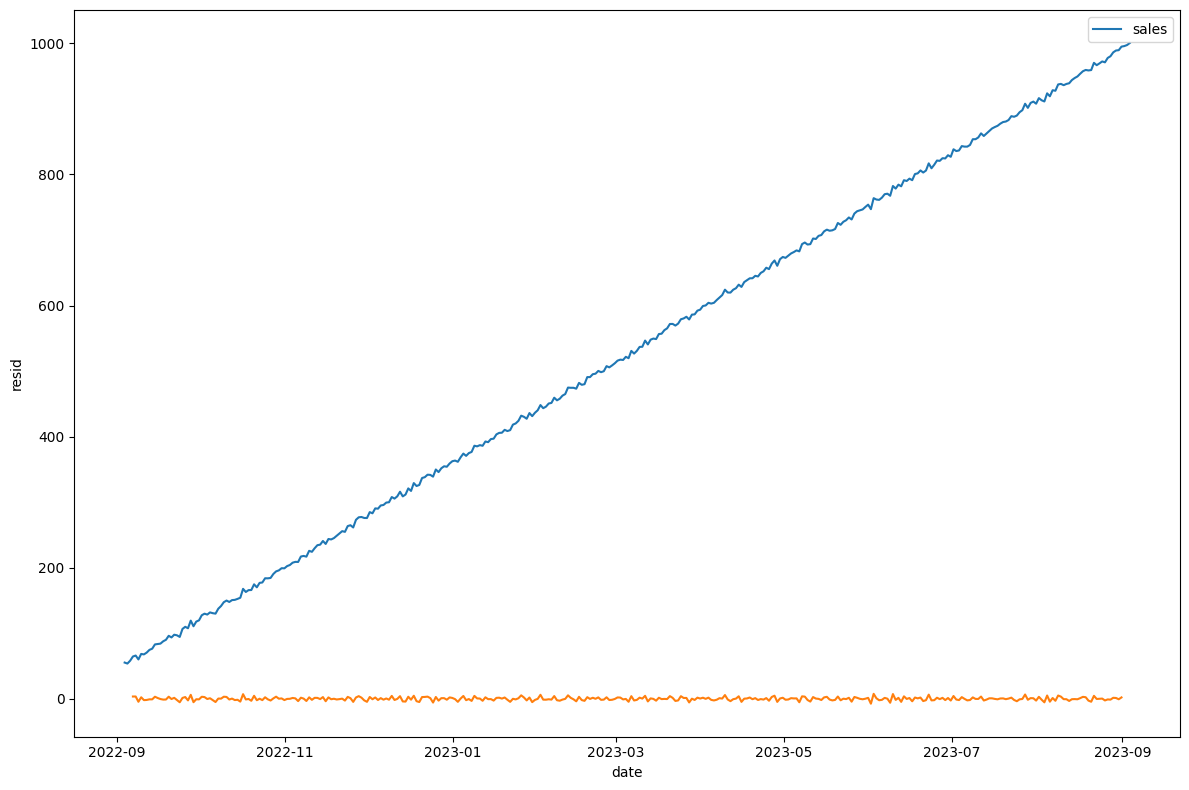

In [40]:
residual = decomposition.resid
fig, axes = plt.subplots(figsize=(12, 8))
sns.lineplot(data=ser, ax=axes)
sns.lineplot(data=residual, ax=axes)
plt.tight_layout()
plt.show()


Los residuos se mantienen cercanos a cero, lo que indica un **bajo nivel de ruido.** La mayor parte del compotamiento de la serie está explicada por la tendencia creciente.

## 3. Entrenamiento del modelo ARIMA

In [45]:
ts = ser['sales']
ts

date
2022-09-03 17:10:08.079328      55.292157
2022-09-04 17:10:08.079328      53.803211
2022-09-05 17:10:08.079328      58.141693
2022-09-06 17:10:08.079328      64.530899
2022-09-07 17:10:08.079328      66.013633
                                 ...     
2023-08-30 17:10:08.079328     989.600354
2023-08-31 17:10:08.079328     994.987326
2023-09-01 17:10:08.079328     995.814415
2023-09-02 17:10:08.079328     997.350214
2023-09-03 17:10:08.079328    1000.482785
Name: sales, Length: 366, dtype: float64

<Axes: xlabel='date'>

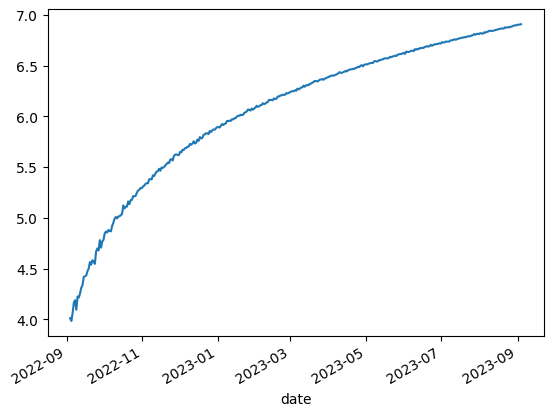

In [48]:
# Transformación logarítmica para estabilizar la varianza
ts_log = np.log(ts)
ts_log.plot()

<Axes: xlabel='date'>

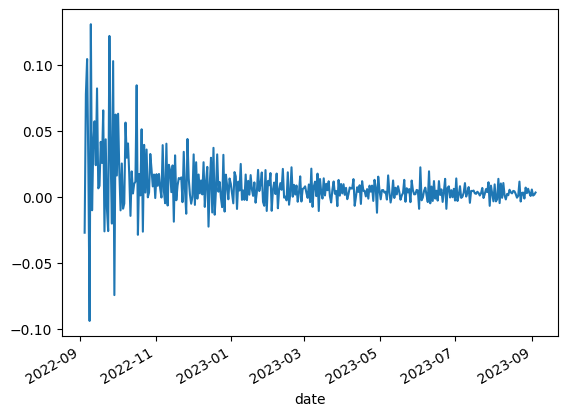

In [50]:
# Diferenciación para eliminar la tendencia
ts_diff = ts_log.diff().dropna()
ts_diff.plot()

<Axes: xlabel='date'>

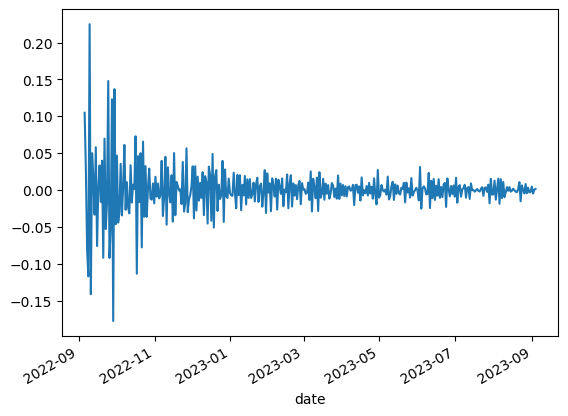

In [54]:
# Eliminamos patrones repetitivos
test_stationary = ts_diff.diff().dropna()
test_stationary.plot()

In [55]:
# Prueba de estacionariedad después de la transformación
test_stationarity(test_stationary)

Resultado de la Prueba de Dickey-Fuller:


Test Statistic                -8.543341e+00
p-value                        9.649856e-14
#Lags Used                     1.700000e+01
Number of Observations Used    3.460000e+02
Critical Value (1%)           -3.449392e+00
Critical Value (5%)           -2.869930e+00
Critical Value (10%)          -2.571240e+00
dtype: float64

Dado que p-value es significativamente menor que 0.05, se rechaza H0, por lo tanto se concluye que la serie es estacionaria tras la transformación aplicada.

In [56]:
#Búsuqeda automática de parámetros para ARIMA
model = auto_arima(ts_log, seasonal=True, m=30, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(1,0,1)[30]             : AIC=-1934.916, Time=3.66 sec
 ARIMA(0,2,0)(0,0,0)[30]             : AIC=-1473.360, Time=0.05 sec
 ARIMA(1,2,0)(1,0,0)[30]             : AIC=-1675.296, Time=0.91 sec
 ARIMA(0,2,1)(0,0,1)[30]             : AIC=-1838.361, Time=1.81 sec
 ARIMA(2,2,2)(0,0,1)[30]             : AIC=-1938.520, Time=3.14 sec
 ARIMA(2,2,2)(0,0,0)[30]             : AIC=-1956.203, Time=0.58 sec
 ARIMA(2,2,2)(1,0,0)[30]             : AIC=-1942.534, Time=2.46 sec
 ARIMA(1,2,2)(0,0,0)[30]             : AIC=-2025.069, Time=0.61 sec
 ARIMA(1,2,2)(1,0,0)[30]             : AIC=-1999.322, Time=1.76 sec
 ARIMA(1,2,2)(0,0,1)[30]             : AIC=-2023.013, Time=2.35 sec
 ARIMA(1,2,2)(1,0,1)[30]             : AIC=-2023.313, Time=2.57 sec
 ARIMA(0,2,2)(0,0,0)[30]             : AIC=-2022.371, Time=0.21 sec
 ARIMA(1,2,1)(0,0,0)[30]             : AIC=-1923.237, Time=0.28 sec
 ARIMA(1,2,3)(0,0,0)[30]             : AIC=-2018.804, Time=0.44 sec
 ARIM

In [57]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  366
Model:               SARIMAX(1, 2, 2)   Log Likelihood                1016.535
Date:                Tue, 28 Apr 2026   AIC                          -2025.069
Time:                        18:51:23   BIC                          -2009.481
Sample:                    09-03-2022   HQIC                         -2018.874
                         - 09-03-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1290      0.029      4.415      0.000       0.072       0.186
ma.L1         -1.8976      0.030    -62.685      0.000      -1.957      -1.838
ma.L2          0.9395      0.031     30.376      0.000       0.879       1.000
sigma2         0.0002   7.46e-06     28.907      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):              4581.06
Prob(Q):                              0.72   Prob(JB):                         0.00
Heteroskedasticity (H):               0.03   Skew:                            -2.09
Prob(H) (two-sided):                  0.00   Kurtosis:                        19.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 4. Predicción con el conjunto de test

In [60]:
forectast = model.predict(n_periods=30)
print(forectast)

2023-09-04 17:10:08.079328    6.911084
2023-09-05 17:10:08.079328    6.913993
2023-09-06 17:10:08.079328    6.916910
2023-09-07 17:10:08.079328    6.919828
2023-09-08 17:10:08.079328    6.922746
2023-09-09 17:10:08.079328    6.925664
2023-09-10 17:10:08.079328    6.928582
2023-09-11 17:10:08.079328    6.931500
2023-09-12 17:10:08.079328    6.934419
2023-09-13 17:10:08.079328    6.937337
2023-09-14 17:10:08.079328    6.940255
2023-09-15 17:10:08.079328    6.943173
2023-09-16 17:10:08.079328    6.946091
2023-09-17 17:10:08.079328    6.949009
2023-09-18 17:10:08.079328    6.951927
2023-09-19 17:10:08.079328    6.954846
2023-09-20 17:10:08.079328    6.957764
2023-09-21 17:10:08.079328    6.960682
2023-09-22 17:10:08.079328    6.963600
2023-09-23 17:10:08.079328    6.966518
2023-09-24 17:10:08.079328    6.969436
2023-09-25 17:10:08.079328    6.972354
2023-09-26 17:10:08.079328    6.975273
2023-09-27 17:10:08.079328    6.978191
2023-09-28 17:10:08.079328    6.981109
2023-09-29 17:10:08.07932

In [61]:
future_dates = pd.date_range(
    start=ser.index[-1],
    periods=31, 
    freq='D'
)[1:]

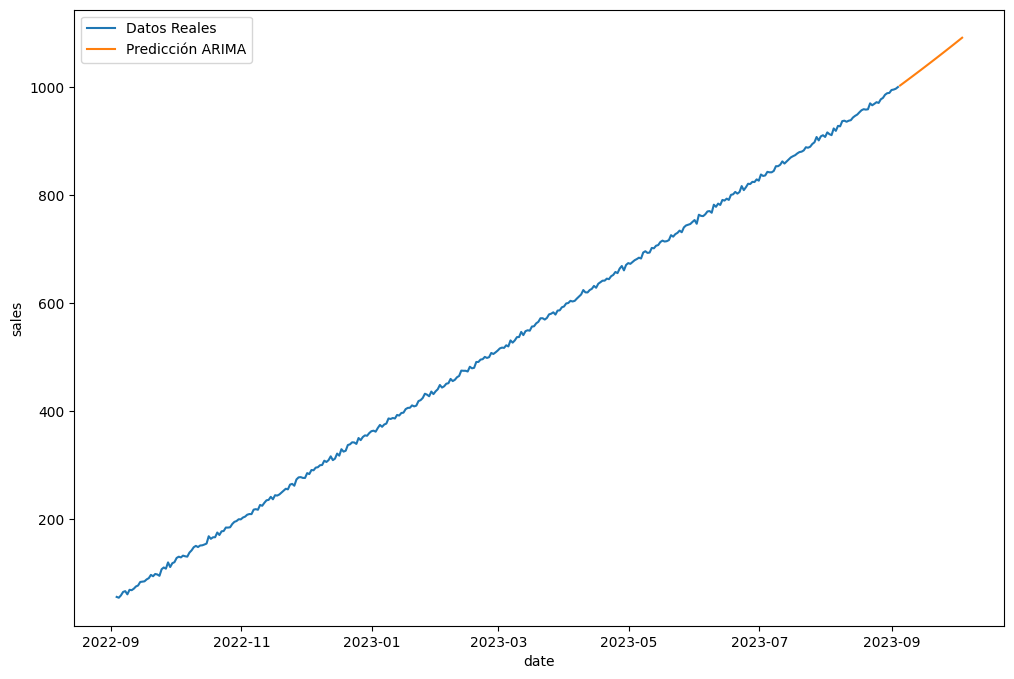

In [63]:
#Grafica de predicciones
fig, axes = plt.subplots(figsize=(12, 8))
sns.lineplot(data=ser['sales'], ax=axes, label='Datos Reales')
sns.lineplot(x=future_dates, y=np.exp(forectast), ax=axes, label='Predicción ARIMA')
plt.legend()
plt.show()

El modelo ARIMA ha logrado capturar correctamente la tendencia creciente de las ventas, reproduciendo un comportamiento muy similar al observado en los datos reales a través de su predicción que mantiene la dirección ascendente de la serie. Esto indica que el modelo es adecuado para extrapolar la evolución futura, al menos, a corto plazo.

In [83]:
#Finalmente dividamos en entrenamiento y prueba para evaluar el modelo
train = ser['sales'][:'2023-05-31']
test = ser['sales']['2023-06':]

In [84]:
#ARIMA sólo con train
model_train = auto_arima(train, seasonal=True, trace=True, stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1362.786, Time=0.52 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1532.902, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1451.440, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1357.248, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1621.211, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1358.934, Time=0.15 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1358.933, Time=0.13 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1361.245, Time=0.18 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1622.022, Time=0.04 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 1.200 seconds


In [85]:
#Predicción sobre test
forecast_test = model_train.predict(n_periods=len(test))
print(forecast_test)

2023-06-01 17:10:08.079328    754.526462
2023-06-02 17:10:08.079328    757.120776
2023-06-03 17:10:08.079328    759.715089
2023-06-04 17:10:08.079328    762.309402
2023-06-05 17:10:08.079328    764.903716
                                 ...    
2023-08-30 17:10:08.079328    988.014660
2023-08-31 17:10:08.079328    990.608973
2023-09-01 17:10:08.079328    993.203286
2023-09-02 17:10:08.079328    995.797600
2023-09-03 17:10:08.079328    998.391913
Freq: D, Length: 95, dtype: float64


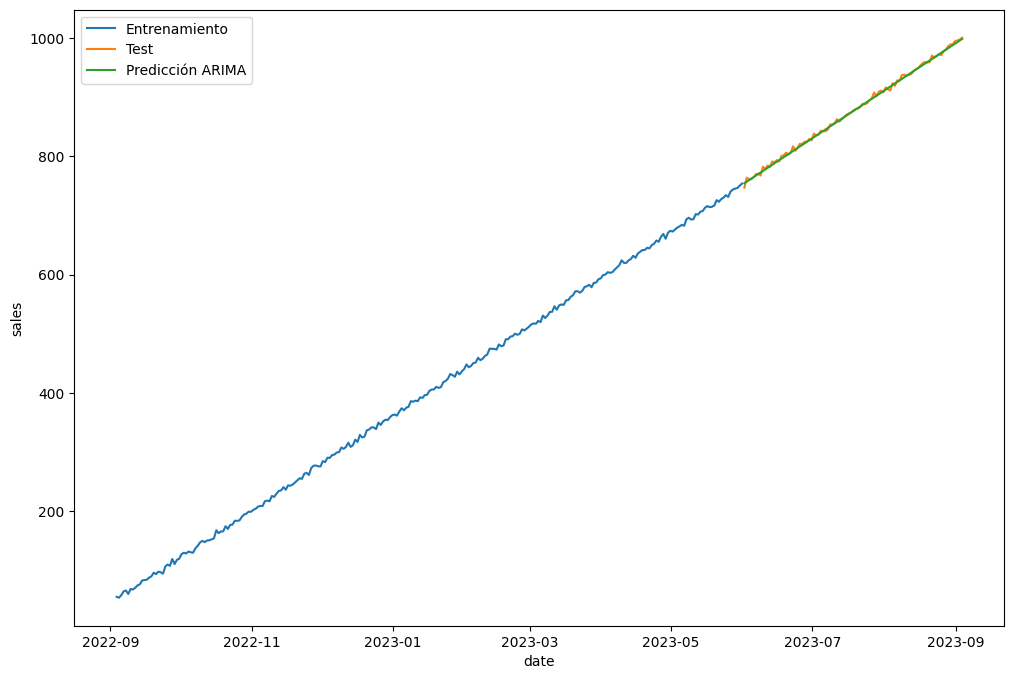

In [86]:
# Visualización real vs predicción
fig, axes = plt.subplots(figsize=(12, 8))
sns.lineplot(data=train, ax=axes, label='Entrenamiento')
sns.lineplot(data=test, ax=axes, label='Test')
sns.lineplot(x=test.index, y=forecast_test, ax=axes, label='Predicción ARIMA')
plt.legend()
plt.show()

**La predicción ARIMA encaja muy bien con el test: sigue la tendencia ascendente casi de forma paralela**

## 5. Guardar el modelo

In [88]:
import joblib
joblib.dump(model_train, "../models/sales/arima_model.pkl")

['../models/sales/arima_model.pkl']